In [1]:
## Task 4 - Neural Networks ##

# Import libraries #
import pandas as pd
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import(
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

In [2]:
# Load exact training and testing datasets from Tasks 2 and 3. #

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [3]:
# Standadise the predictor variables. #
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# Task 4.2 - Neural Network - All Predictor Variables. #

# Create neural network model.
nn_full = MLPClassifier(
    random_state=42,
    max_iter=500
)

In [5]:
# Define hyperparameters to test. #

param_grid_full = {
    'hidden_layer_sizes': [
        (50,),
        (100,),
        (50, 25),
        (100, 50)
    ],
    'activation' : ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init' : [0.001, 0.01]
} 

In [6]:
# Prepare the grid search with cross validation. #

grid_full = GridSearchCV(
    estimator=nn_full,
    param_grid=param_grid_full,
    cv=10,
    scoring='roc_auc',
    n_jobs=-1
)

In [7]:
# Train the model with the training data. #

grid_full.fit(X_train_scaled, y_train)

c:\Users\NevilleDoyle\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GridSearchCV(cv=10, estimator=MLPClassifier(max_iter=500, random_state=42),
             n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(50,), (100,), (50, 25),
                                                (100, 50)],
                         'learning_rate_init': [0.001, 0.01]},
             scoring='roc_auc')

In [14]:
# Print the parameters. #

best_nn_full = grid_full.best_estimator_

print("Best parameters: ")
print(grid_full.best_params_)

print(f"Best cross-validation ROC-AUC: {grid_full.best_score_:.4f}")

Best parameters: 
{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}
Best cross-validation ROC-AUC: 0.7119


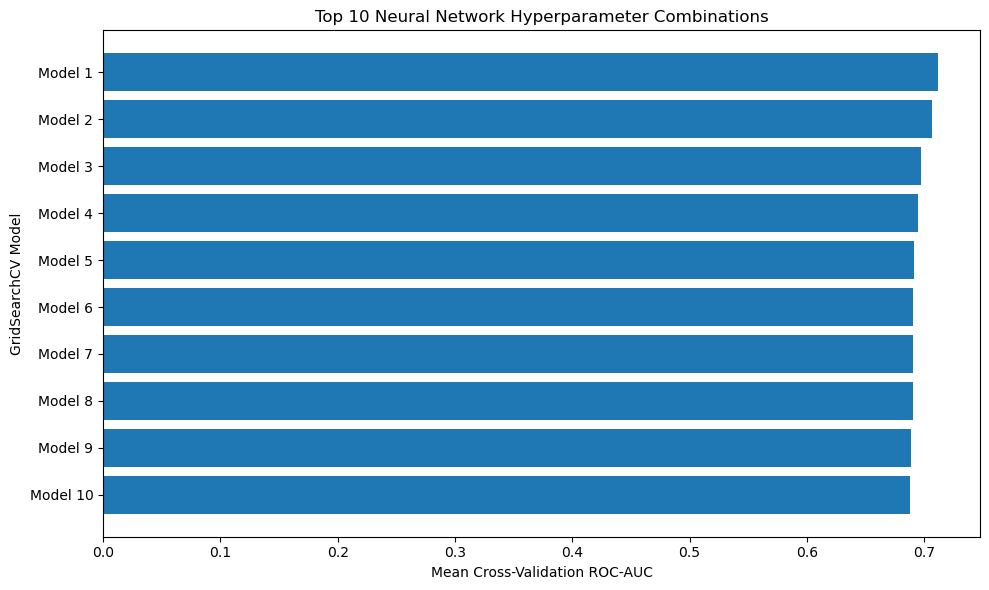

In [16]:
# Plot the 10 best GridSearchCV parameter combinations #

cv_results = pd.DataFrame(grid_full.cv_results_)

top_10 = (
    cv_results
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .copy()
)

top_10['Model'] = [
    f"Model {i}" for i in range(1, len(top_10) + 1)
]

plt.figure(figsize=(10, 6))

plt.barh(
    top_10['Model'][::-1],
    top_10['mean_test_score'][::-1]
)

plt.xlabel('Mean Cross-Validation ROC-AUC')
plt.ylabel('GridSearchCV Model')
plt.title('Top 10 Neural Network Hyperparameter Combinations')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate training and test performance. #

y_train_pred = best_nn_full.predict(X_train_scaled) # Predictions
y_test_pred = best_nn_full.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred) # Accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Training accuracy: 0.9076
Test accuracy: 0.8879


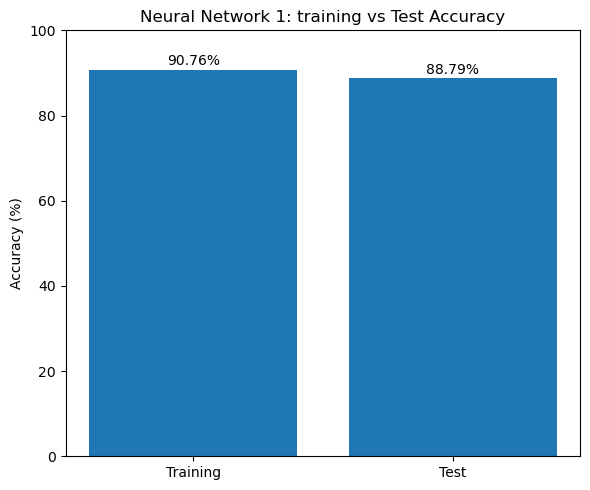

In [20]:
# Plot training and test accuracy. #
accuracy_values = [
    train_accuracy * 100,
    test_accuracy * 100
]

plt.figure(figsize=(6, 5))

bars = plt.bar(
    ['Training', 'Test'],
    accuracy_values
)

plt.ylabel('Accuracy (%)')
plt.title('Neural Network 1: training vs Test Accuracy')
plt.ylim(0, 100)

for bar, value in zip(bars, accuracy_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f'{value:.2f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

In [ ]:
# Iterations and convergence. #

print("Iterations: ", best_nn_full.n_iter_)
print("final loss: ", best_nn_full.loss_)

Iterations:  96
final loss:  0.27969415911017204


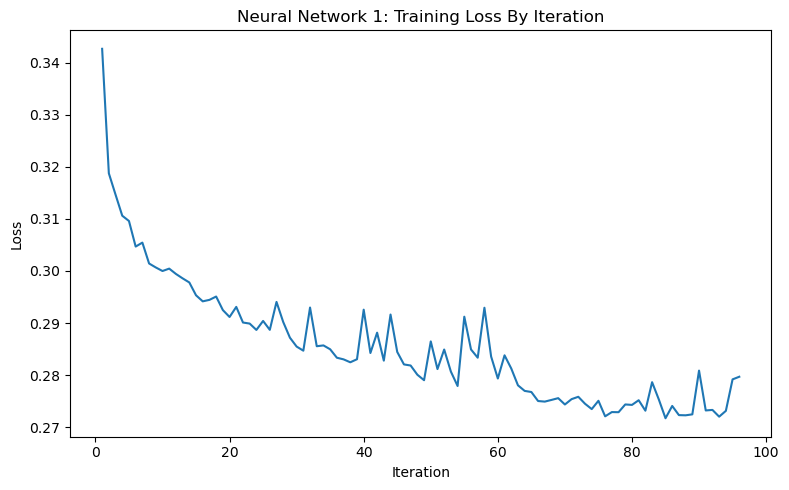

In [22]:
# Plot training loss across iterations. #
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(best_nn_full.loss_curve_) + 1),
    best_nn_full.loss_curve_
)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Neural Network 1: Training Loss By Iteration')

plt.tight_layout()
plt.show()

In [ ]:
# ROC-AUC Curve. #

#Probability of IsBadBuy = 1
y_test_prob = best_nn_full.predict_proba(X_test_scaled)[:, 1]

#ROC-AUC
auc_full = roc_auc_score(y_test, y_test_prob)

print(f"Test ROC-AUC: {auc_full:.4f}")

Test ROC-AUC: 0.7266


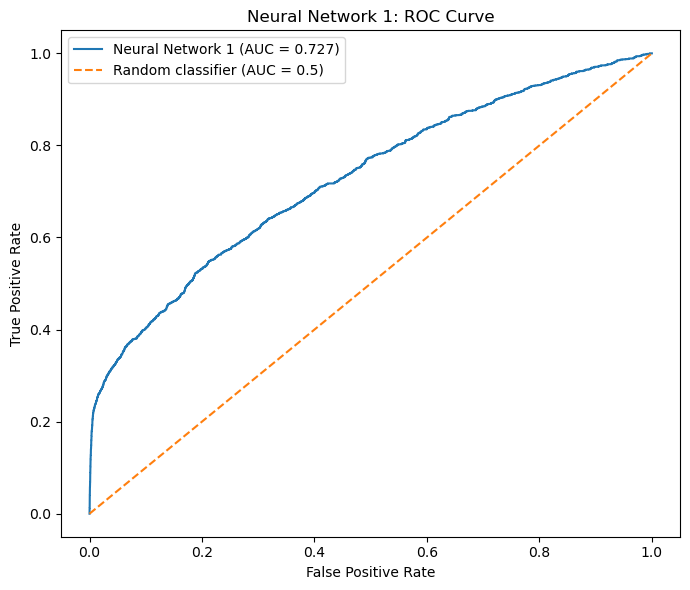

In [24]:
# Calculate ROC curve #

fpr_full, tpr_full, threshholds_full = roc_curve(
    y_test,
    y_test_prob
)

#Plot ROC curve #
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_full,
    tpr_full,
    label=f'Neural Network 1 (AUC = {auc_full:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random classifier (AUC = 0.5)'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Neural Network 1: ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
# 10 fold cross validation ROC-AUC scores. #
print(f"Best cross-validation ROC-AUC: {grid_full.best_score_:.4f}")


Best cross-validation ROC-AUC: 0.7119
